# Examen Tema 4: Modelos ML

Para cada ejercicio se tendrá en cuenta:

* La validez del código
* La interpretación de resultados y respuestas de preguntas. 
* Ausencia de errores y warnings en la salida

El examen es secuencial, pero si te falta algo de un ejercicio es mejor avanzar a quedarse atascado.

El objetivo del examen es preparar los datos para hacer Regresión Lineal mediante OLS y Lasso y comparar ambos modelos.

## Dataset

Es un dataset de venta de coches de segunda mano.

Como se puede ver en la primera celda de código, no existen valores nulos.

__La variable objetivo de la Regresión Lineal es el precio (selling_price)__. Esta variable ha sido convertida a dólares.

Cada ejercicio son 2 puntos.

In [148]:
import pandas as pd
import numpy as np

# Cargar el dataset
df = pd.read_csv('car.csv')

# 1. Definir el tipo de cambio (Aprox: 1 Rupia = 0.012 Dólares)
tipo_cambio = 0.012

# 2. Convertir la variable objetivo a dólares
df['selling_price'] = df['selling_price'] * tipo_cambio

# 3. Información técnica y nulos
print("\n--- Información del Dataset ---")
print(df.info())

# 4. Visualización inicial
print("\n--- Primeras 5 filas ---")
df.head()


--- Información del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           4340 non-null   object 
 1   year           4340 non-null   int64  
 2   selling_price  4340 non-null   float64
 3   km_driven      4340 non-null   int64  
 4   fuel           4340 non-null   object 
 5   seller_type    4340 non-null   object 
 6   transmission   4340 non-null   object 
 7   owner          4340 non-null   object 
dtypes: float64(1), int64(2), object(5)
memory usage: 271.4+ KB
None

--- Primeras 5 filas ---


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,720.000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,1620.000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,7200.000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,3000.000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,5400.000,141000,Diesel,Individual,Manual,Second Owner


## Columnas

+ name: Nombre del modelo del vehículo. Es categórica con demasiados valores únicos, esta no nos interesa y será eliminada.
+ year: Año de matriculación.
+ selling_price: Precio de venta. Esta será la __variable objetivo__.
+ km_driven: Kilómetros.
+ fuel: Tipo de combustible. Categórica. Valores posibles ['Petrol' 'Diesel' 'CNG' 'LPG' 'Electric']
+ seller_type: Tipo de vendedor (si es particular, empresa, etc). Categórica. Valores posibles ['Individual' 'Dealer' 'Trustmark Dealer']
+ transmission: Tipo de transmisión. Categórica. Valores posibles ['Manual' 'Automatic']
+ Owner: Generación de propietarios (coche seminuevo o km0, primera mano, segunda mano...). Categórica. Valors posibles  ['First Owner' 'Second Owner' 'Fourth & Above Owner' 'Third Owner' 'Test Drive Car']

En la siguiente celda se visualizan los valores únicos de las columnas categóricas.

In [149]:
# Identificamos las columnas que son de tipo objeto (categóricas)
columnas_categoricas = df.select_dtypes(include=['object']).columns

print("--- VALORES ÚNICOS POR COLUMNA CATEGÓRICA ---")
print("-" * 45)

for col in columnas_categoricas:
    valores = df[col].unique()
    num_valores = len(valores)
    print(f"Columna: '{col}' ({num_valores} valores únicos)")
    
    # Si tiene muchos valores (como 'name'), solo mostramos los primeros 5
    if num_valores > 10:
        print(f"  Ejemplos: {valores[:5]}...")
    else:
        print(f"  Valores: {valores}")
    print("-" * 45)

--- VALORES ÚNICOS POR COLUMNA CATEGÓRICA ---
---------------------------------------------
Columna: 'name' (1491 valores únicos)
  Ejemplos: ['Maruti 800 AC' 'Maruti Wagon R LXI Minor' 'Hyundai Verna 1.6 SX'
 'Datsun RediGO T Option' 'Honda Amaze VX i-DTEC']...
---------------------------------------------
Columna: 'fuel' (5 valores únicos)
  Valores: ['Petrol' 'Diesel' 'CNG' 'LPG' 'Electric']
---------------------------------------------
Columna: 'seller_type' (3 valores únicos)
  Valores: ['Individual' 'Dealer' 'Trustmark Dealer']
---------------------------------------------
Columna: 'transmission' (2 valores únicos)
  Valores: ['Manual' 'Automatic']
---------------------------------------------
Columna: 'owner' (5 valores únicos)
  Valores: ['First Owner' 'Second Owner' 'Fourth & Above Owner' 'Third Owner'
 'Test Drive Car']
---------------------------------------------


# Ejercicio 1. Codificación de variables

Es necesario transformar el dataset con los siguientes cambios

1. Elimina la columna "name" ya que tiene 1491 valores únicos y hacer OneHotEncoding con ellas sería poco útil. Esta columna no será usada.
2. Cambia la columna 'year' por 'antiguedad' ya que es más práctico tener años de antiguedad del vehículo. Se crea una columna nueva haciendo 2026-year y borramos year.
3. Codifica 'owner' con Label Encoding. Aunque es categórica es lógico aplicar esta codificación, pues km0 es mejor que un coche de 3ª mano. El valor 0 es Test Drive Car y el resto 1,2...secuencialmente.
4. Codifca 'transmission' con Label Enconding al ser binaria.
5. Codifica 'fuel' y 'seller_type' con One-Hot Enconding, sin redundancias, valores 0/1 en lugar de booleanos.


In [163]:
df_encoded = df.drop(columns=['name'])
df_encoded.columns =['antiguedad', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner']

df_encoded['owner'] = df_encoded['owner'].map({'Test Drive Car': 0, 'First Owner': 1, 'Second Owner': 2, 'Third Owner': 3, 'Fourth & Above Owner': 4})
df_encoded['transmission'] = df_encoded['transmission'].map({'Manual': 0, 'Automatic': 1})
df_encoded = pd.get_dummies(df_encoded, columns=['fuel', 'seller_type'], drop_first=True, dtype=int)

df_encoded.head()

,antiguedad,selling_price,km_driven,transmission,owner,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer
0,2007,720.000,70000,0,1,0,0,0,1,1,0
1,2007,1620.000,50000,0,1,0,0,0,1,1,0
2,2012,7200.000,100000,0,1,1,0,0,0,1,0
3,2017,3000.000,46000,0,1,0,0,0,1,1,0
4,2014,5400.000,141000,0,2,1,0,0,0,1,0


# Ejercicio 2. Correlación de variables

Calcula y muestra en un gráfico las correlaciones entre variables

__Responde a la pregunta__: ¿Qué 5 variables están más correlacionadas con la variable objetivo?

- Antiguedad
- Transmission
- seller_type_Trustmark Dealer	
- fuel_Diesel
- fuel_Electric

La correlación indica la relación entre cada variable y el precio.

Valores cercanos a 1 indican relación positiva fuerte.

In [154]:
correlaciones = df_encoded[['antiguedad', 'km_driven', 'transmission', 'owner', 'fuel_Diesel', 'fuel_Electric', 'fuel_LPG', 'fuel_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'selling_price']].corr()
correlaciones

,antiguedad,km_driven,transmission,owner,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,selling_price
antiguedad,1.000,-0.420,0.144,-0.469,0.121,-0.026,-0.051,-0.115,-0.174,0.100,0.414
km_driven,-0.420,1.000,-0.120,0.322,0.285,-0.001,0.037,-0.291,0.183,-0.090,-0.192
transmission,0.144,-0.120,1.000,-0.083,0.048,0.045,-0.025,-0.040,-0.214,0.042,0.530
owner,-0.469,0.322,-0.083,1.000,-0.002,0.012,0.030,-0.008,0.266,-0.089,-0.228
fuel_Diesel,0.121,0.285,0.048,-0.002,1.000,-0.015,-0.072,-0.971,-0.035,-0.008,0.283
fuel_Electric,-0.026,-0.001,0.045,0.012,-0.015,1.000,-0.001,-0.015,-0.026,-0.002,-0.005
fuel_LPG,-0.051,0.037,-0.025,0.030,-0.072,-0.001,1.000,-0.071,0.035,-0.011,-0.042
fuel_Petrol,-0.115,-0.291,-0.040,-0.008,-0.971,-0.015,-0.071,1.000,0.030,0.012,-0.269
seller_type_Individual,-0.174,0.183,-0.214,0.266,-0.035,-0.026,0.035,0.030,1.000,-0.267,-0.237
seller_type_Trustmark Dealer,0.100,-0.090,0.042,-0.089,-0.008,-0.002,-0.011,0.012,-0.267,1.000,0.110


# Ejercicio 3. División y escalado

+ Separa del dataset la variable objetivo en el vector y. Guarda en X la matriz de características.
+ Divide el dataset en 2 conjuntos, entrenamiento y test, 80/20.
+ Transforma y ajusta un Escalador usando el conjunto X de entrenamiento y luego aplícalo al conjunto X de test.

Variables predictoras X:


,antiguedad,km_driven,transmission,owner,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer
0,2007,70000,0,1,0,0,0,1,1,0
1,2007,50000,0,1,0,0,0,1,1,0
2,2012,100000,0,1,1,0,0,0,1,0
3,2017,46000,0,1,0,0,0,1,1,0
4,2014,141000,0,2,1,0,0,0,1,0


Variable objetivo y:


0    720.000
1   1620.000
2   7200.000
3   3000.000
4   5400.000
Name: selling_price, dtype: float64

------------------------------------------------------------------------------------------------
Registros totales: 4340
Registros de entrenamiento:  3472 -> 80.00%
Registros de test:  868 -> 20.00%
------------------------------------------------------------------------------------------------


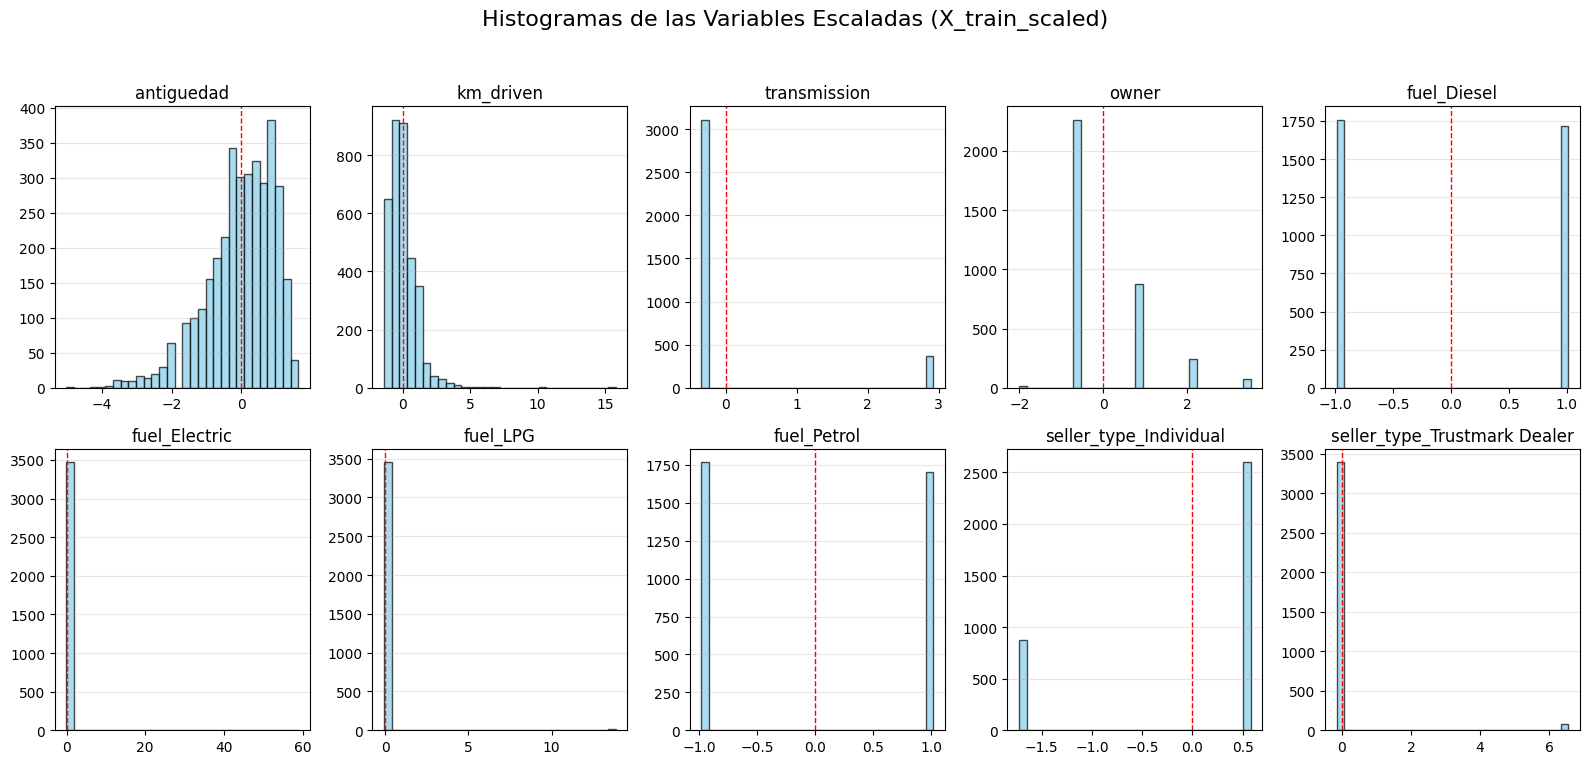

In [ ]:
X = df_encoded[['antiguedad', 'km_driven', 'transmission', 'owner', 'fuel_Diesel', 'fuel_Electric', 'fuel_LPG', 'fuel_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer']]
y = df_encoded['selling_price']

print("Variables predictoras X:")
display(X.head())

print("Variable objetivo y:")
display(y.head())

print("------------------------------------------------------------------------------------------------")
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verificamos las dimensiones para estar seguros
print(f"Registros totales: {X.shape[0]}")
print(f"Registros de entrenamiento:  {X_train.shape[0]} -> {(X_train.shape[0]*100/X.shape[0]):.2f}%")
print(f"Registros de test:  {X_test.shape[0]} -> {(X_test.shape[0]*100/X.shape[0]):.2f}%")

print("------------------------------------------------------------------------------------------------")

# Visualización de histogramas previo al escalado
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# 4. Escalado
scaler = StandardScaler()
# Aplicamos el algoritmo a los datos de entrenamiento
X_train_scaled = scaler.fit_transform(X_train) # devuelve un ndarray de numpy
# Transformamos también los datos de test
X_test_scaled = scaler.transform(X_test)


# Configuramos la figura (2 filas, 4 columnas)
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(16, 8))
fig.suptitle('Histogramas de las Variables Escaladas (X_train_scaled)', fontsize=16)

# Aplanamos el array de ejes para iterar fácilmente
axes = axes.flatten()

# Nombres de las columnas originales para los títulos
columns = ['antiguedad', 'km_driven', 'transmission', 'owner', 'fuel_Diesel', 'fuel_Electric', 'fuel_LPG', 'fuel_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer']

for i in range(len(columns)):
    # Histograma columna i
    axes[i].hist(X_train_scaled[:, i], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(columns[i])
    axes[i].grid(axis='y', alpha=0.3)
    # Dibujamos una línea roja en el 0 para verificar el centrado
    axes[i].axvline(0, color='red', linestyle='dashed', linewidth=1)

# Ajustamos el diseño para que no se solapen los títulos
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()



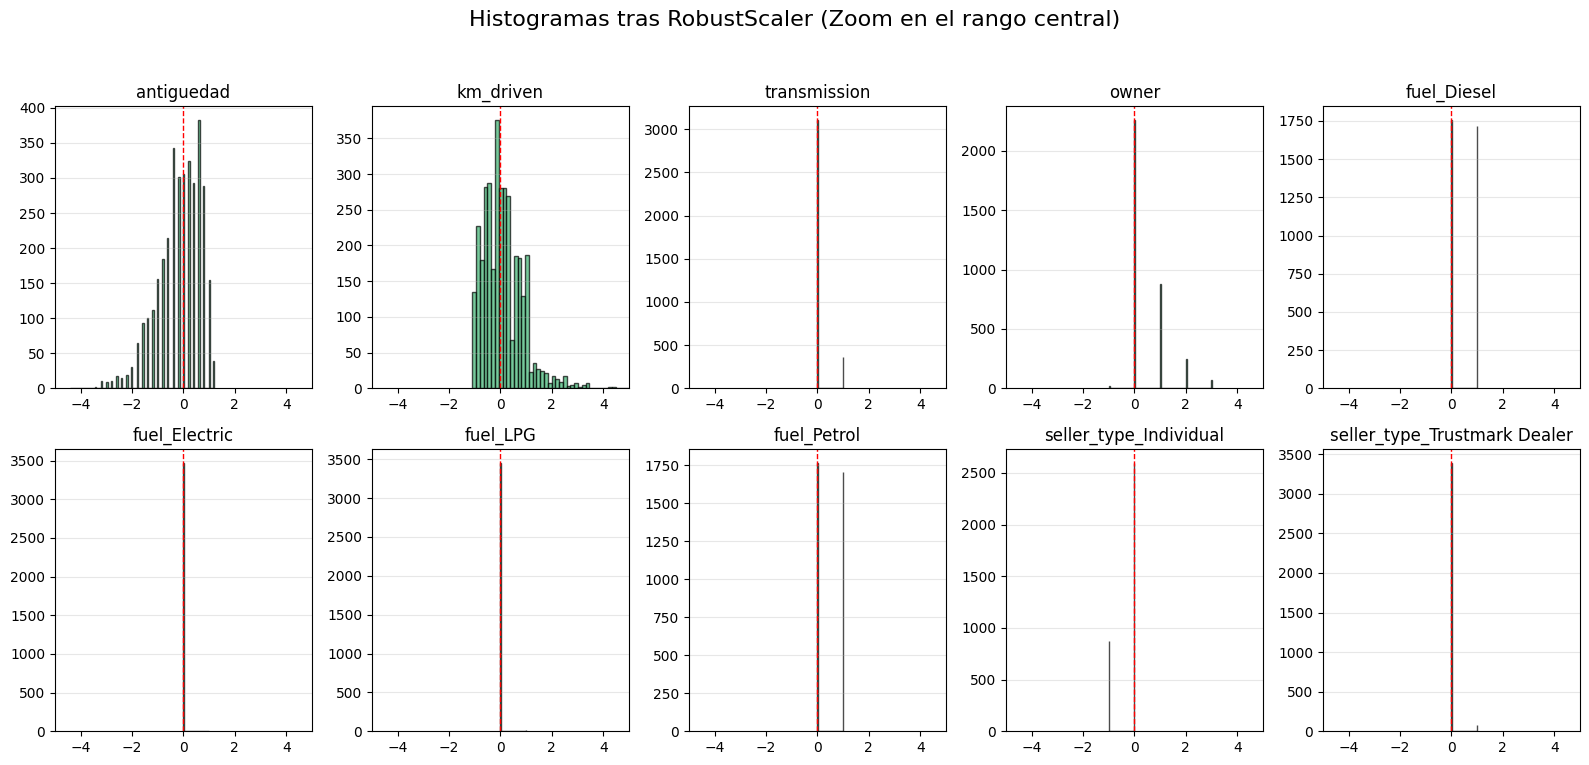

In [ ]:
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt

# 1. Instanciar y aplicar RobustScaler
robust_scaler = RobustScaler()
X_train_robust = robust_scaler.fit_transform(X_train)
X_test_robust = robust_scaler.transform(X_test)

# 2. Configurar la visualización (2 filas, 4 columnas)
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(16, 8))
fig.suptitle('Histogramas tras RobustScaler (Zoom en el rango central)', fontsize=16)

axes = axes.flatten()
columns = ['antiguedad', 'km_driven', 'transmission', 'owner', 'fuel_Diesel', 'fuel_Electric', 'fuel_LPG', 'fuel_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer']

for i in range(len(columns)):
    # Graficamos el histograma
    axes[i].hist(X_train_robust[:, i], bins=100, color='mediumseagreen', edgecolor='black', alpha=0.7)
    axes[i].set_title(columns[i])
    
    # IMPORTANTE: Hacemos "zoom" automático al rango donde está el 99% de los datos
    # para que los outliers no nos impidan ver la campana.
    axes[i].set_xlim(-5, 5) 
    
    axes[i].grid(axis='y', alpha=0.3)
    axes[i].axvline(0, color='red', linestyle='dashed', linewidth=1) # Línea en la Mediana

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression, Lasso
import numpy as np

# 1. Regresión Lineal Básica (OLS)
ols_model = LinearRegression()
ols_model.fit(X_train_robust, y_train)


# 2. Regresión Lasso (Regularización L1)
# Hiperparámetro alpha controla la simplicidad del modelo resultante
# VAlors de 0 a infinito. Cuanto más grande, más variables descartará (coeficientes a 0)
# Con alpha=0 se comporta como OLS
# Entre 0.001 - 0.01 penalización suave
# Entre 0.1 y 1 penalización media
# Se puede probar entre varios valores, comparando modelos resultantes
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train_robust, y_train)

# Cálculo de coeficientes eliminados por Lasso
num_coef_0 = np.sum(lasso_model.coef_ == 0)
# Averiguamos cuáles son las columnas con coeficientes a 0 con indexación booleana
columns = ['antiguedad', 'km_driven', 'transmission', 'owner', 'fuel_Diesel', 'fuel_Electric', 'fuel_LPG', 'fuel_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer']
variables_eliminadas = np.array(columns)[lasso_model.coef_ == 0]

print("--- Resultados del Entrenamiento ---")
print(f"OLS entrenado correctamente.")
print(f"Lasso ha enviado {num_coef_0} coeficientes a cero.")
if num_coef_0 > 0:
    print(f"Variables descartadas por Lasso: {variables_eliminadas}")

print("-"*20)
# Para que los arrays de Numpy no usen notación científica (suprimir notación 'e')
np.set_printoptions(suppress=True, precision=3)
print("--- Coeficientes de los modelos ---\n")
# Hacemos un DataFrame para mostrar los coeficientes de cada modelo de forma más estructurada
df_coefs = pd.DataFrame({
    'Nombre Variable': columns,
    'Coef_OLS': ols_model.coef_,
    'Coef_Lasso': lasso_model.coef_
})
df_coefs

--- Resultados del Entrenamiento ---
OLS entrenado correctamente.
Lasso ha enviado 0 coeficientes a cero.
--------------------
--- Coeficientes de los modelos ---



,Nombre Variable,Coef_OLS,Coef_Lasso
0,antiguedad,2167.163,2167.498
1,km_driven,-675.047,-674.911
2,transmission,10683.068,10680.889
3,owner,-178.896,-178.694
4,fuel_Diesel,3349.411,3366.248
5,fuel_Electric,-7889.565,-7522.775
6,fuel_LPG,602.506,599.970
7,fuel_Petrol,-252.565,-235.556
8,seller_type_Individual,-882.090,-881.721
9,seller_type_Trustmark Dealer,2019.913,2015.675


# Ejercicio 4. OLS (mínimos cuadrados ordinarios)

+ Entrena un modelo de Regresión Lineal OLS
+ Muestra el vector de coeficientes
+ __Responde a las preguntas__:
    + ¿Cuál es la variable que más influye en el precio final?
    + ¿Qué influencia tiene en el precio final de venta aumentar 1 año de antiguedad?

In [ ]:
from sklearn.linear_model import LinearRegression
modelo = LinearRegression()

modelo.fit(X_train_robust, y_train)

print("Intercepto b0:", modelo.intercept_)

coeficientes = pd.DataFrame({
    "variable": X.columns,
    "coeficiente": modelo.coef_
})

coeficientes.sort_values(by="coeficiente", ascending=False)

Intercepto b0: 3715.309290734953


,variable,coeficiente
2,transmission,10683.068
4,fuel_Diesel,3349.411
0,antiguedad,2167.163
9,seller_type_Trustmark Dealer,2019.913
6,fuel_LPG,602.506
3,owner,-178.896
7,fuel_Petrol,-252.565
1,km_driven,-675.047
8,seller_type_Individual,-882.090
5,fuel_Electric,-7889.565


# Ejercicio 4. Regresión Lineal con penalización Lasso

+ Entrena un modelo con penalizacón Lasso con alpha=500
+ Muestra el vector de coeficientes
+ Respnode a las preguntas:
    + ¿Cuáles son las características/variables puestas a 0 por Lasso? ¿cuáles son las que usa para el modelo?
    + ¿Cómo relacionas la respuesta anterior con la matriz de correlación calculada anteriormente?

In [ ]:
from sklearn.linear_model import Lasso

columns = ['antiguedad', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner']
print(f"Columnas: {columns}")

# El hiperparámetro alpha indica la cantidad de regularización
# Cuanto más alto, más coeficientes pondrá a 0
alphas = [0.01, 10, 100, 500] 
for a in alphas:
    lasso_model = Lasso(alpha=a)
    lasso_model.fit(X_train_robust, y_train)
    # Contamos cuántos coeficientes son CERO
    eliminados = sum(lasso_model.coef_ == 0)
    print(f"\nAlpha {a}: Variables eliminadas: {eliminados} de {len(columns)}")
    print(f"Coeficientes {lasso_model.coef_}")

Columnas: ['antiguedad', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner']

Alpha 0.01: Variables eliminadas: 0 de 7
Coeficientes [ 2167.19615884  -675.03373291 10682.84854021  -178.87491033
  3351.22829005 -7852.75064572   602.38561072  -250.73346034
  -882.05340857  2019.48773336]

Alpha 10: Variables eliminadas: 2 de 7
Coeficientes [ 2182.34248467  -659.68021004 10565.75692364  -168.93651441
  3308.14708817    -0.             0.          -243.4318057
  -879.39429235  1582.24386977]

Alpha 100: Variables eliminadas: 4 de 7
Coeficientes [2258.42166556 -530.87564005 9740.20263017  -81.80074179 3125.51901524
   -0.            0.           -0.         -739.45407509    0.        ]

Alpha 500: Variables eliminadas: 7 de 7
Coeficientes [2342.42958509   -0.         5994.03088752   -0.         1380.71214998
    0.            0.           -0.           -0.            0.        ]


## Ejercicio 5. Métricas y rendimiento

+ Calcula, haciendo las predicciones del conjunto de test, las métricas MAE, RMSE, R2 ajustado y muéstralas
+ Muestra en 2 nubes de puntos, una para cada modelo, los residuos. Esto es, en el Eje X el valor y_test real y en el eje Y el valor y_test predicho para comprar.
+ __Analiza los resultados__

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Función auxiliar para calcular el r2 ajustado a partir de r2
def calcular_r2_ajustado(r2, n, p):
    """Calcula el R2 ajustado: n=muestras, p=variables"""
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

# Creamos una función que recibe un modelo y dataset de test (datos y objetivo)
# Retorna un diccionario con nombre del modelo y las 3 métricas
def calcular_metricas(nombre_modelo, modelo, X_test, y_test):
    # Usamos el modelo para precedir la variable objetivo
    y_pred = modelo.predict(X_test)

    # CÁLCULO DE MÉTRICAS
    # R2
    r2 = r2_score(y_test, y_pred)
    # R2 ajustado
    n = len(y_test) # Número de observaciones
    p = X_test.shape[1] # Número de variables
    r2_aj = calcular_r2_ajustado(r2, n, p)
    # MAE
    mae = mean_absolute_error(y_test, y_pred)
    # RMSE
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # Diccionario de retorno
    return {
        'Modelo': nombre_modelo,
        'R2_Ajustado': r2_aj,
        'MAE': mae,
        'RMSE': rmse
    }

# Evaluamos los 2 modelos entrenados anteriormente
res_ols = calcular_metricas("OLS", ols_model, X_test_robust, y_test)
res_lasso = calcular_metricas("Lasso", lasso_model, X_test_robust, y_test)

# Creamos el DataFrame comparativo
df_comparativa = pd.DataFrame([res_ols, res_lasso])

# Para que los DataFrames de Pandas muestren 3 decimales (0.575 en vez de 5.7e-01)
pd.options.display.float_format = '{:.3f}'.format

# Mostramos la tabla
df_comparativa

,Modelo,R2_Ajustado,MAE,RMSE
0,OLS,0.395,2664.843,5127.107
1,Lasso,0.347,2605.894,5324.767


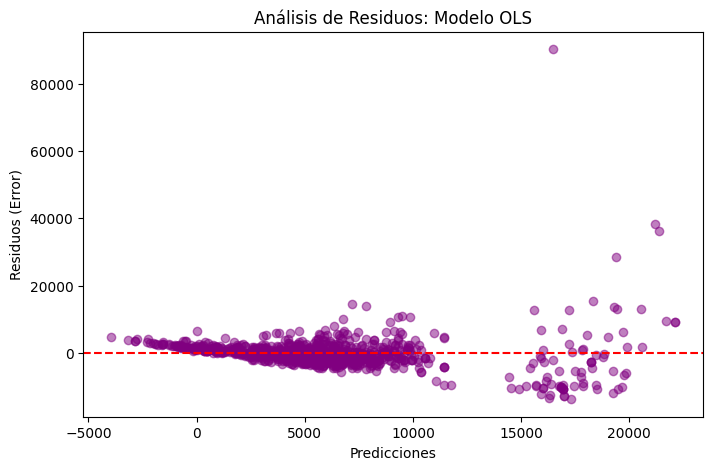

In [ ]:
# Visualización de Residuos del modelo OLS
y_pred = ols_model.predict(X_test_robust)
residuos = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuos, alpha=0.5, color='purple')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicciones")
plt.ylabel("Residuos (Error)")
plt.title("Análisis de Residuos: Modelo OLS")
plt.show()

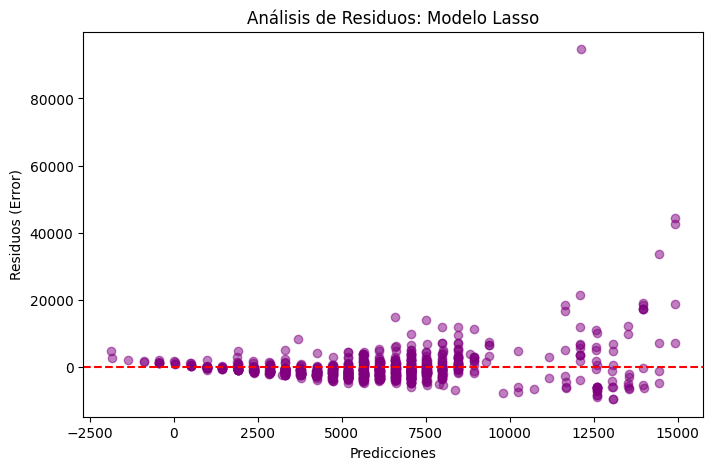

In [ ]:
# Visualización de Residuos del modelo Lasso
y_pred = lasso_model.predict(X_test_robust)
residuos = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuos, alpha=0.5, color='purple')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicciones")
plt.ylabel("Residuos (Error)")
plt.title("Análisis de Residuos: Modelo Lasso")
plt.show()